<a href="https://colab.research.google.com/github/aadiptasg-star/Leaf-disease-detection-model/blob/main/leaf_disease_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

%cd '/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset'

In [ ]:
import os
/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Test

folder_path = '/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset'

def total_files(folder_path):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    return num_files

train_files_healthy = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train/Healthy"
train_files_powdery = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train/Powdery"
train_files_rust = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train/Rust"

test_files_healthy = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Test/Healthy"
test_files_powdery = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Test/Powdery"
test_files_rust = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Test/Rust"

valid_files_healthy = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Validation/Healthy"
valid_files_powdery = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Validation/Powdery"
valid_files_rust = "/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Validation/Rust"

print("Number of healthy leaf images in training set", total_files(train_files_healthy))
print("Number of powder leaf images in training set", total_files(train_files_powdery))
print("Number of rusty leaf images in training set", total_files(train_files_rust))

print("========================================================")

print("Number of healthy leaf images in test set", total_files(test_files_healthy))
print("Number of powder leaf images in test set", total_files(test_files_powdery))
print("Number of rusty leaf images in test set", total_files(test_files_rust))

print("========================================================")

print("Number of healthy leaf images in validation set", total_files(valid_files_healthy))
print("Number of powder leaf images in validation set", total_files(valid_files_powdery))
print("Number of rusty leaf images in validation set", total_files(valid_files_rust))


Number of healthy leaf images in training set 438
Number of powder leaf images in training set 410
Number of rusty leaf images in training set 414
Number of healthy leaf images in test set 50
Number of powder leaf images in test set 50
Number of rusty leaf images in test set 50
Number of healthy leaf images in validation set 20
Number of powder leaf images in validation set 20
Number of rusty leaf images in validation set 20


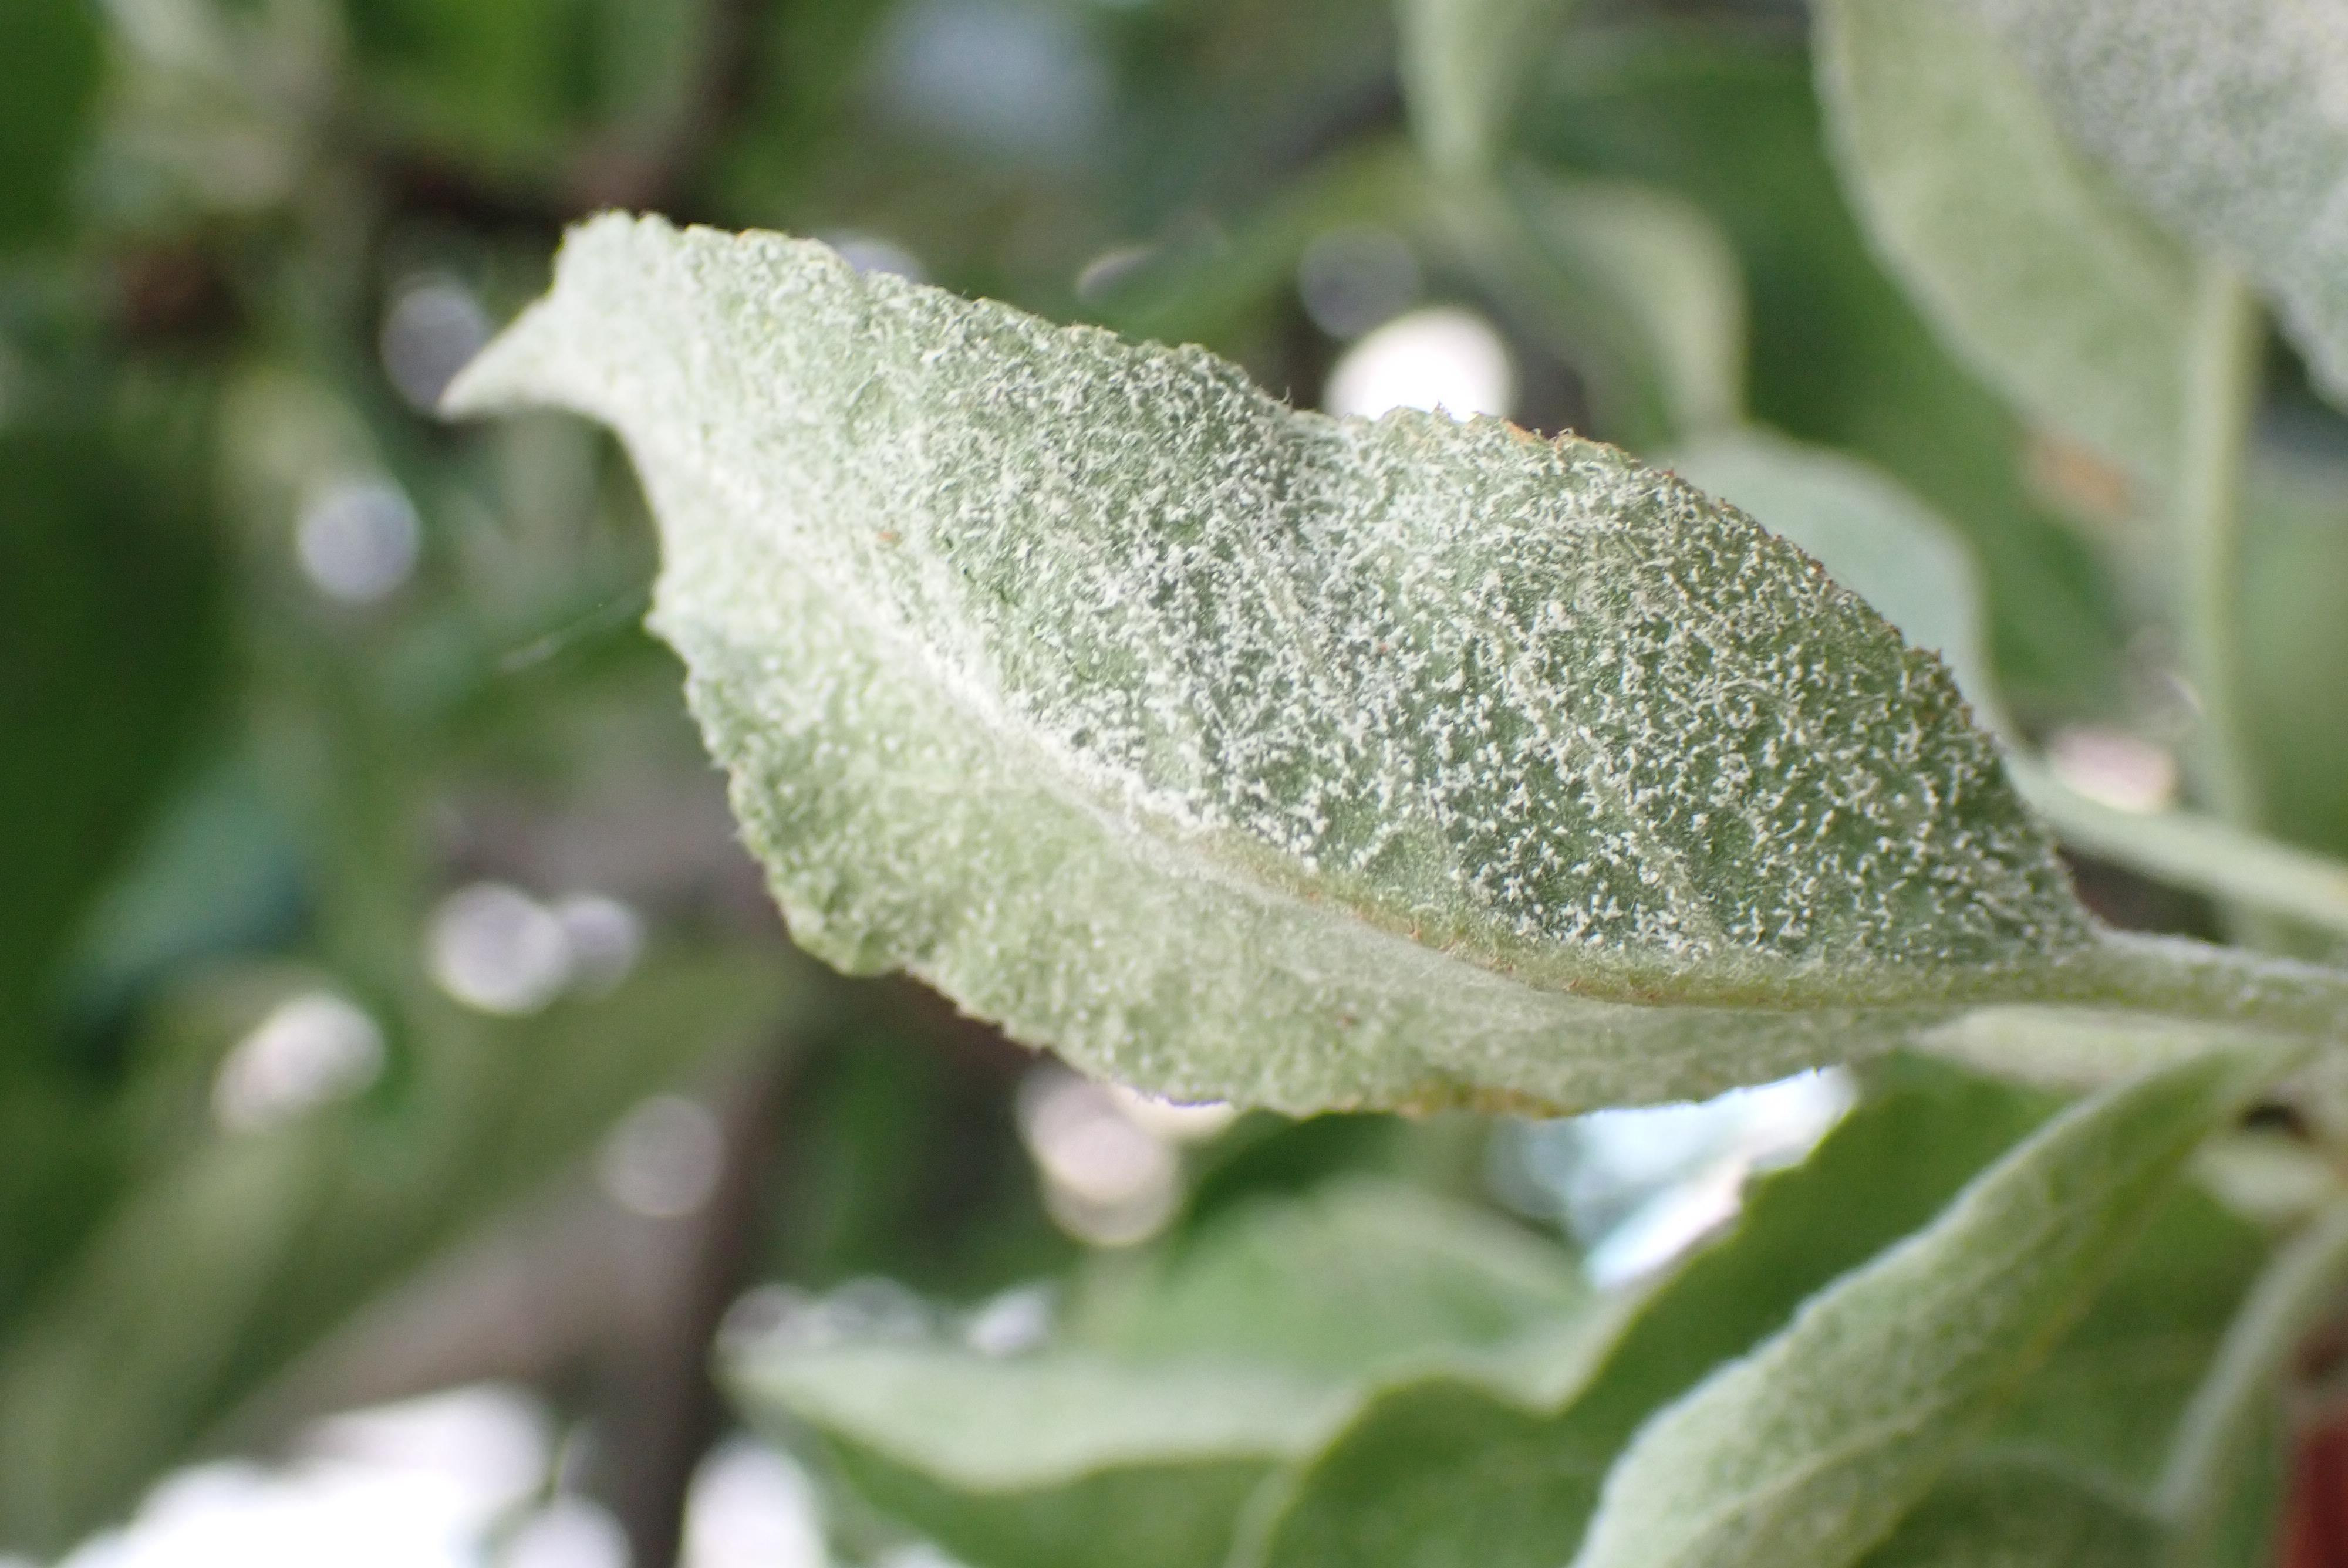

In [ ]:
from PIL import Image
import IPython.display as display

image_path = '/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train/Powdery/802f7439ec1ef0cd.jpg'

with open(image_path, 'rb') as f:
    display.display(display.Image(data=f.read(), width=500))

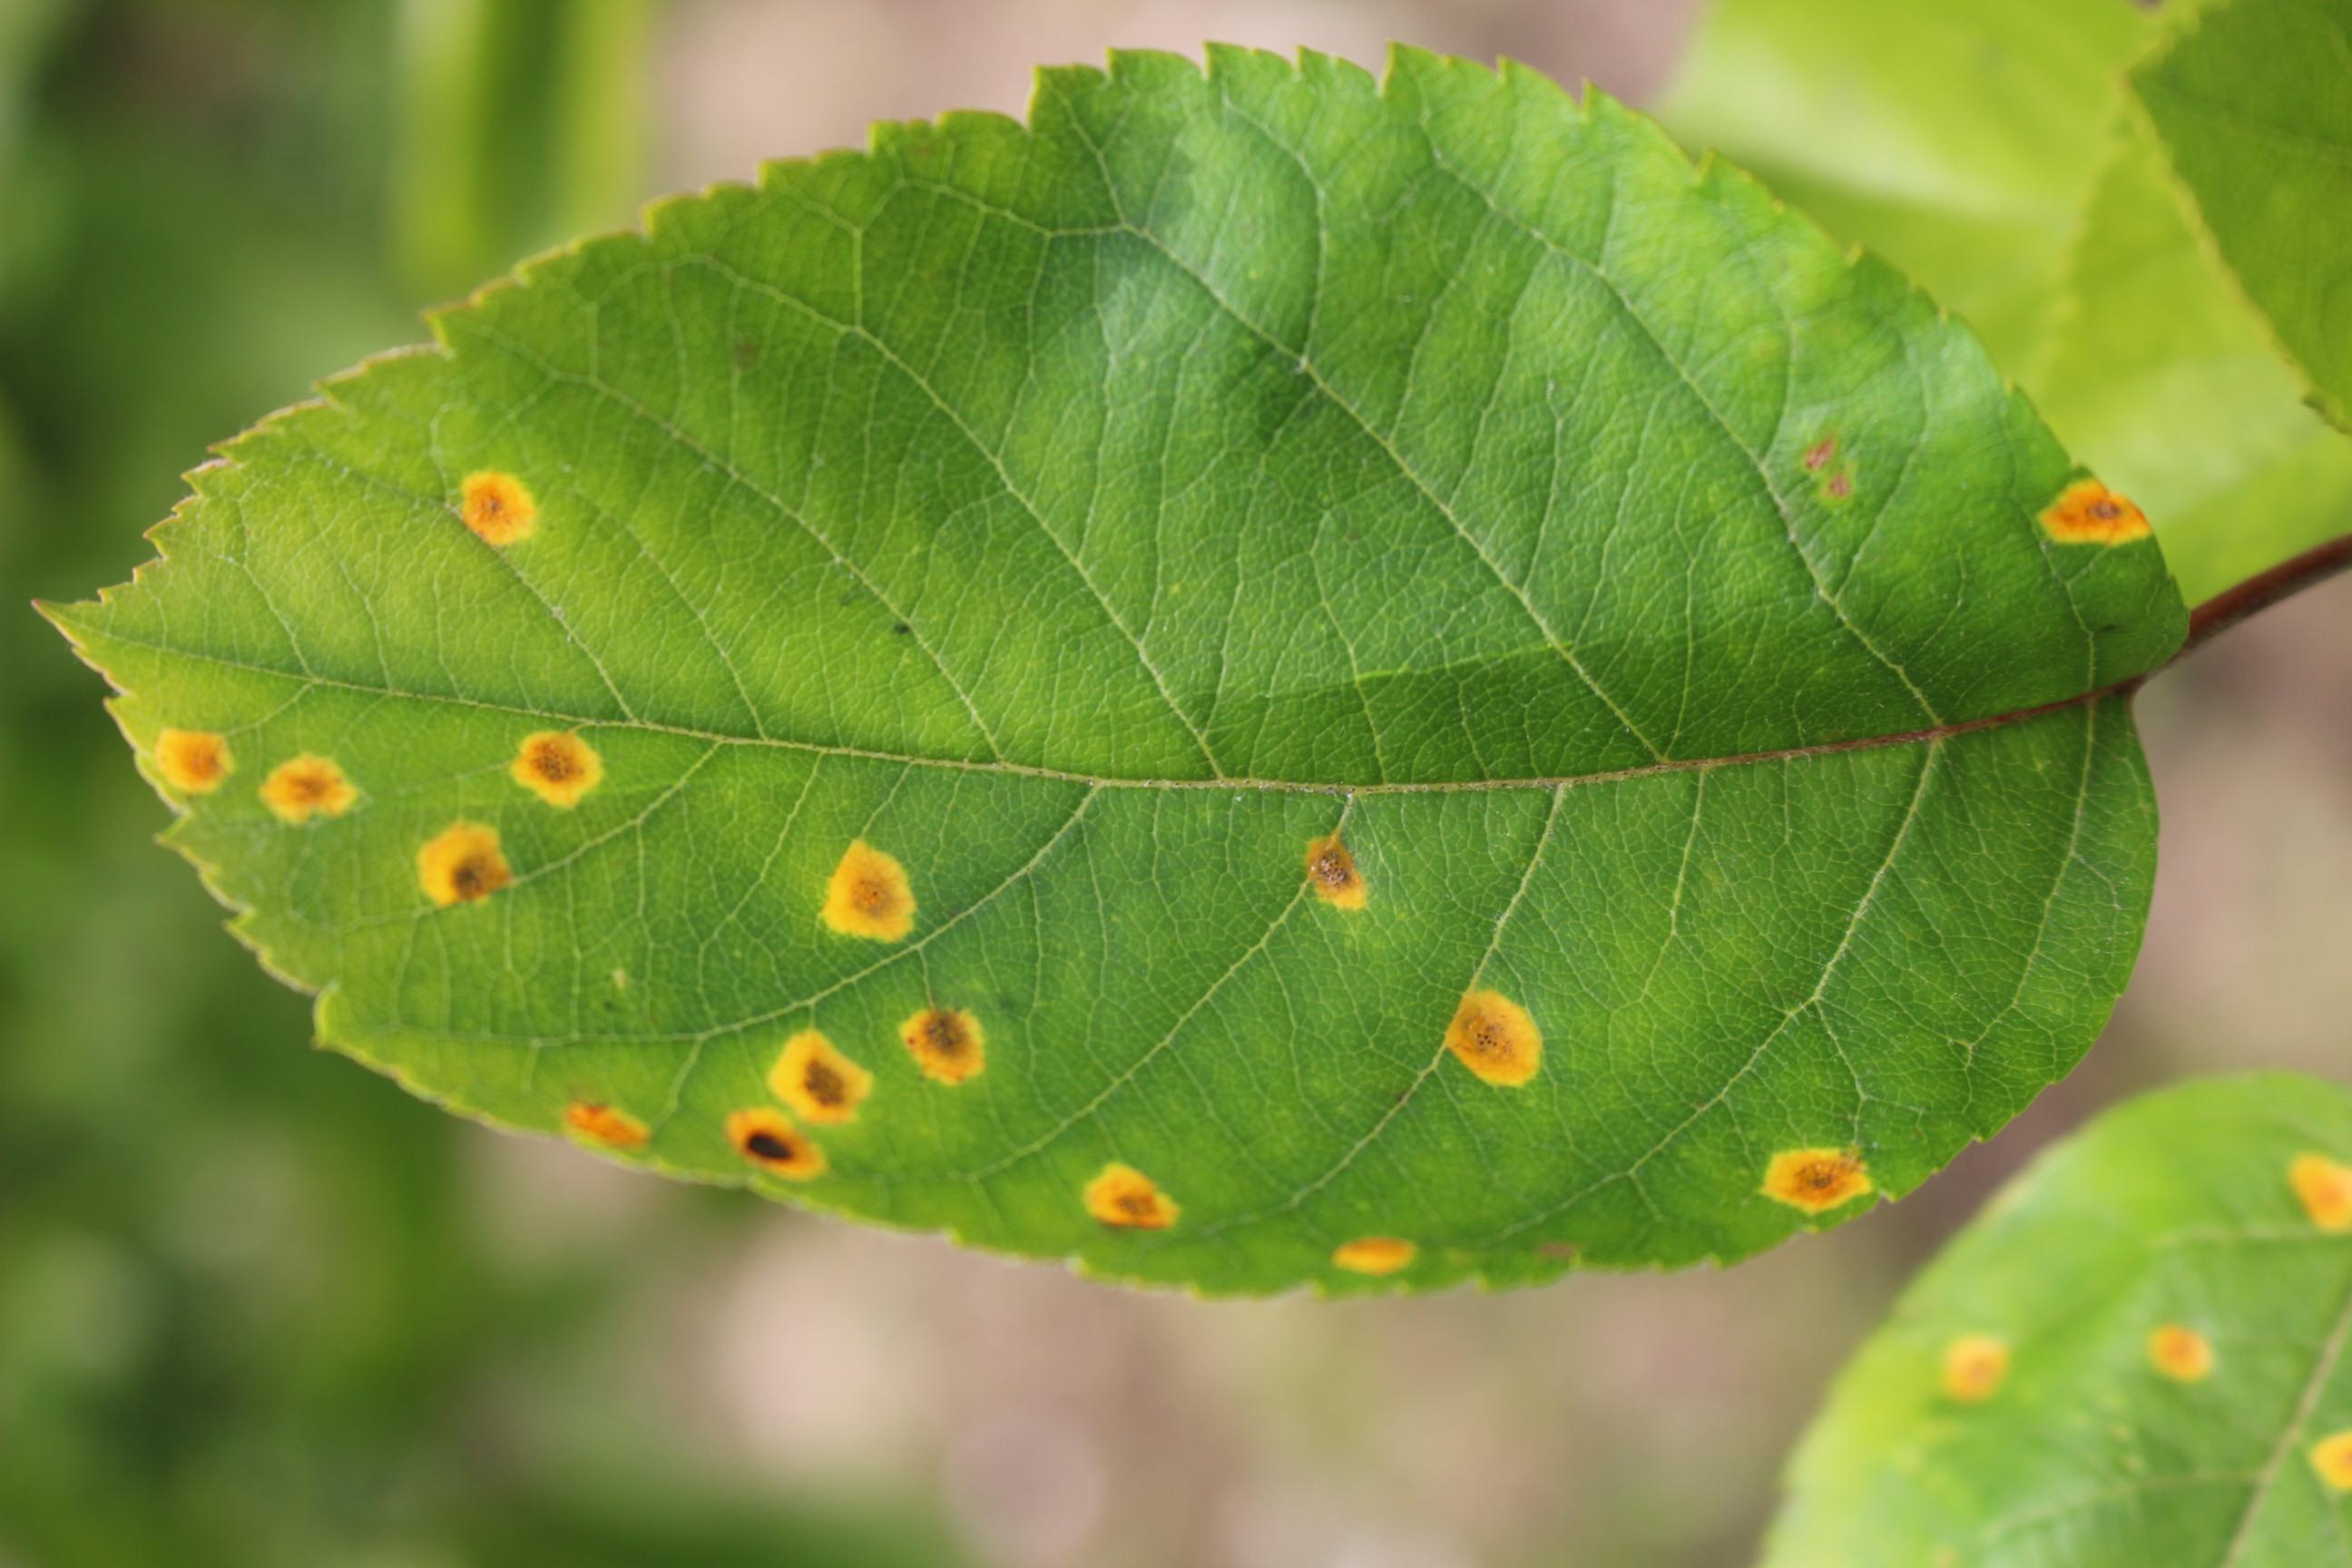

In [ ]:
image_path = '/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train/Rust/80f09587dfc7988e.jpg'

with open(image_path, 'rb') as f:
    display.display(display.Image(data=f.read(), width=600))

In [ ]:
import tensorflow as tf

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory('/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Train',
                                                    target_size=(225, 225),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory('/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Validation',
                                                        target_size=(225, 225),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1262 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(225, 225, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator,
                    batch_size=16,
                    epochs=5,
                    validation_data=validation_generator
                    )

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 355s 8s/step - accuracy: 0.3818 - loss: 3.1475 - val_accuracy: 0.7167 - val_loss: 0.6843
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 238s 5s/step - accuracy: 0.7064 - loss: 0.6747 - val_accuracy: 0.8333 - val_loss: 0.5333
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 298s 6s/step - accuracy: 0.8931 - loss: 0.3004 - val_accuracy: 0.7500 - val_loss: 1.0069
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 313s 6s/step - accuracy: 0.8954 - loss: 0.2741 - val_accuracy: 0.9167 - val_loss: 0.2548
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 329s 6s/step - accuracy: 0.9286 - loss: 0.2345 - val_accuracy: 0.9000 - val_loss: 0.3156


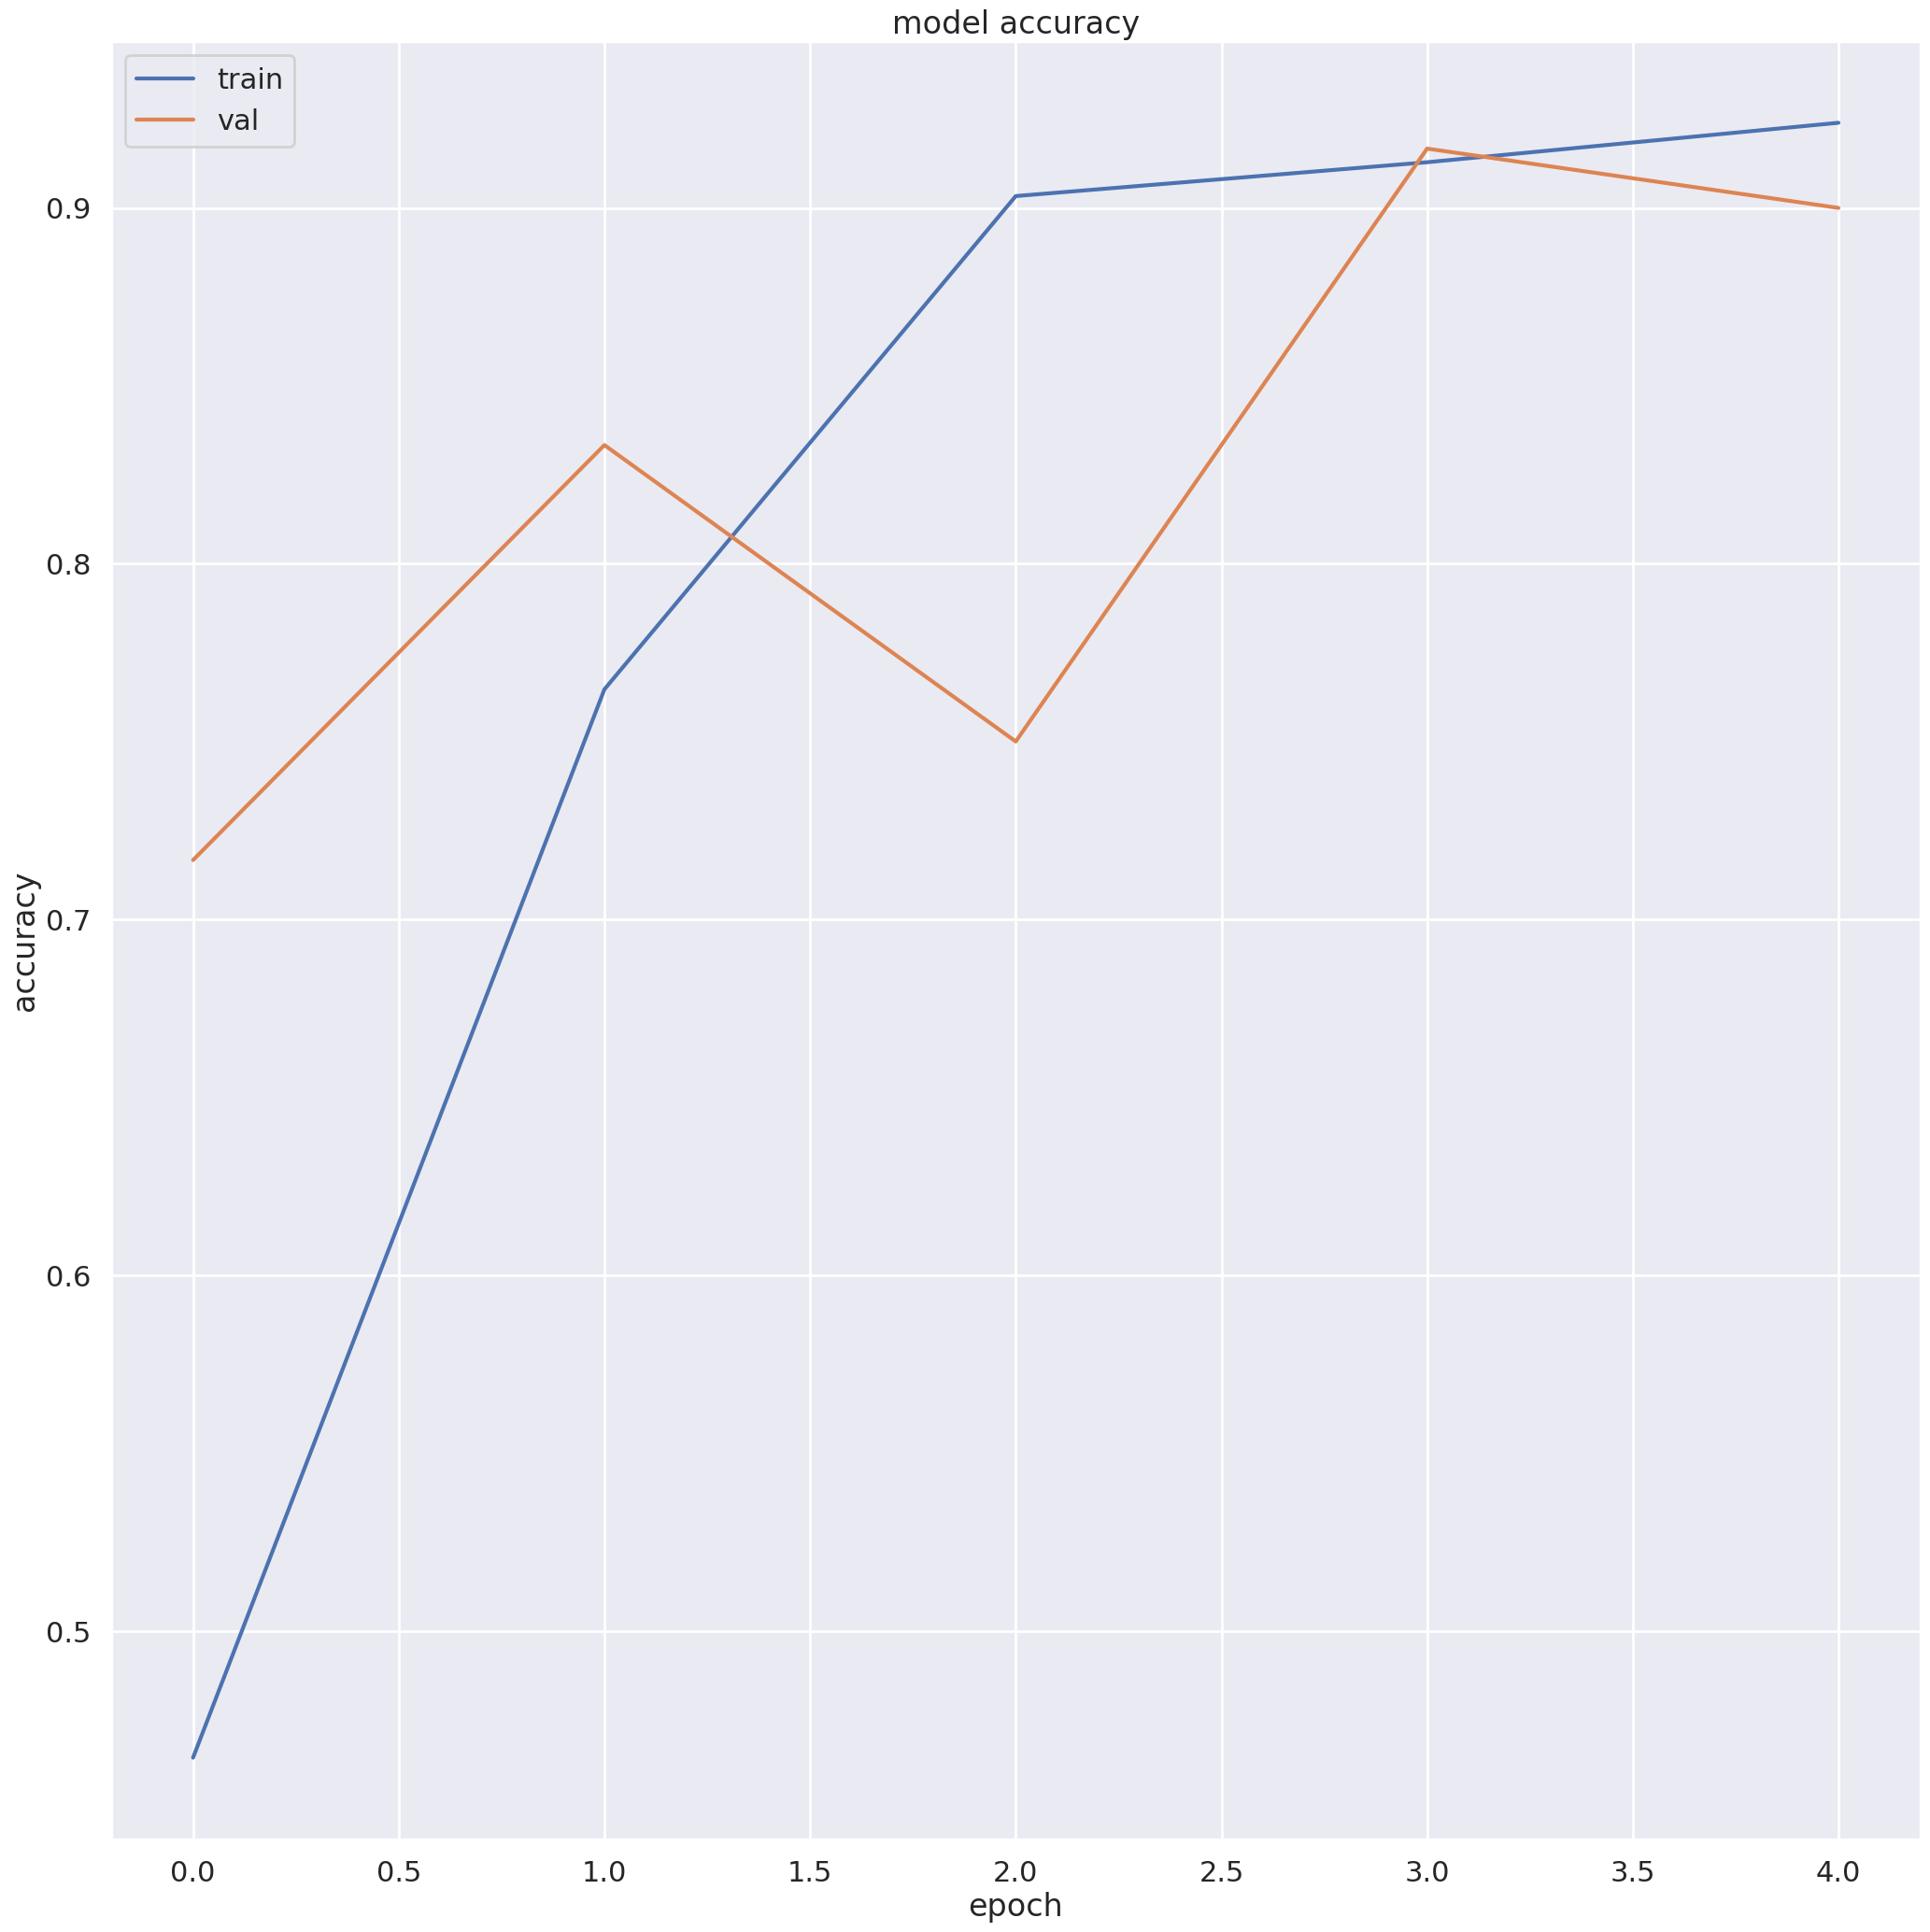

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure

import seaborn as sns
sns.set_theme()
sns.set_context("poster")

figure(figsize=(25, 25), dpi=100)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def preprocess_image(image_path, target_size=(225, 225)):
    img = load_img(image_path, target_size=target_size)
    x = img_to_array(img)
    x = x.astype('float32') / 255.
    x = np.expand_dims(x, axis=0)
    return x

x = preprocess_image('/content/drive/MyDrive/Artificial_Intelligence_and_Machine_Learning/Practical_materials/Plant disease recognition dataset/Test/Rust/82f49a4a7b9585f1.jpg')

In [ ]:
predictions = model.predict(x)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


array([1.49623705e-02, 1.31531106e-05, 9.85024452e-01], dtype=float32)

In [ ]:
labels = train_generator.class_indices
labels = {v: k for k, v in labels.items()}
labels

{0: 'Healthy', 1: 'Powdery', 2: 'Rust'}

In [ ]:
predicted_label = labels[np.argmax(predictions)]
print(predicted_label)

Rust
